# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# Data Loading

In [2]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Nb stores : {df['Store'].nunique()}")
print(f"Period : {df['Date'].min()} → {df['Date'].max()}")

Shape : (844338, 18)
Nb stores : 1115
Period : 2013-01-01 00:00:00 → 2015-07-31 00:00:00


# Multi-Store Feature Engineering

In [28]:
def make_features_multi(df):
    df = df.copy()
    
    # Date-related features
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

    # Lags
    # IMPORTANT : shift() at group level to avoid mixing stores
    grp = df.groupby('Store')['Sales']
    df['lag_365'] = grp.shift(365)

    # Moving averages
    df['rolling_mean_28'] = grp.shift(1).transform(lambda x: x.rolling(28).mean())

    # Store-related features
    df['Promo']       = df['Promo'].astype(int)
    df['StateHoliday'] = df['StateHoliday'].map(
        {'0': 0, 'a': 1, 'b': 2, 'c': 3}).fillna(0)
    df['StoreType']   = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
    df['Assortment']  = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})

    return df

df_feat = make_features_multi(df)
df_feat = df_feat.dropna()

print(f"Shape post-engineering : {df_feat.shape}")
print(f"Stores covered : {df_feat['Store'].nunique()}")

Shape post-engineering : (134563, 29)
Stores covered : 365


# Train/Test Split

In [31]:
FEATURES = [
    'Store',
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end',
    'lag_365',
    'rolling_mean_28',
    'Promo', 'StateHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance',
]

TARGET = 'Sales'

# The last 6 weeks for testing
cutoff = df_feat['Date'].max() - pd.Timedelta(weeks=6)
train_df = df_feat[df_feat['Date'] <= cutoff].copy()
test_df  = df_feat[df_feat['Date'] > cutoff].copy()

X_train = train_df[FEATURES]
y_train = np.log1p(train_df[TARGET])

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET].values

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Stores for testing : {test_df['Store'].nunique()}")

Train : (121419, 17) | Test : (13144, 17)
Stores for testing : 365


# Model Training

In [32]:
model_multi = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,         # plus élevé qu'en single-store — plus de patterns
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_multi.fit(
    X_train, y_train,
    eval_set=[(X_test, np.log1p(y_test))],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

print(f"Optimal number of estimatores : {model_multi.best_iteration_}")

[100]	valid_0's l2: 0.0216923
[200]	valid_0's l2: 0.0192234
[300]	valid_0's l2: 0.0183046
[400]	valid_0's l2: 0.0177213
[500]	valid_0's l2: 0.0172415
Optimal number of estimatores : 498


# Predictions & Evaluation

In [33]:
y_pred_multi = np.expm1(model_multi.predict(X_test))

mape_global = mean_absolute_percentage_error(y_test, y_pred_multi) * 100
print(f" global multi-stores MAPE: {mape_global:.2f}%")
print(f" store 1 MAPE: 1.68%")

 global multi-stores MAPE: 10.13%
 store 1 MAPE: 1.68%


# Results Analysis

## Store-level MAPE

MAPE médian par store : 9.62%
MAPE min : 5.69% (Store 229)
MAPE max : 35.68% (Store 876)


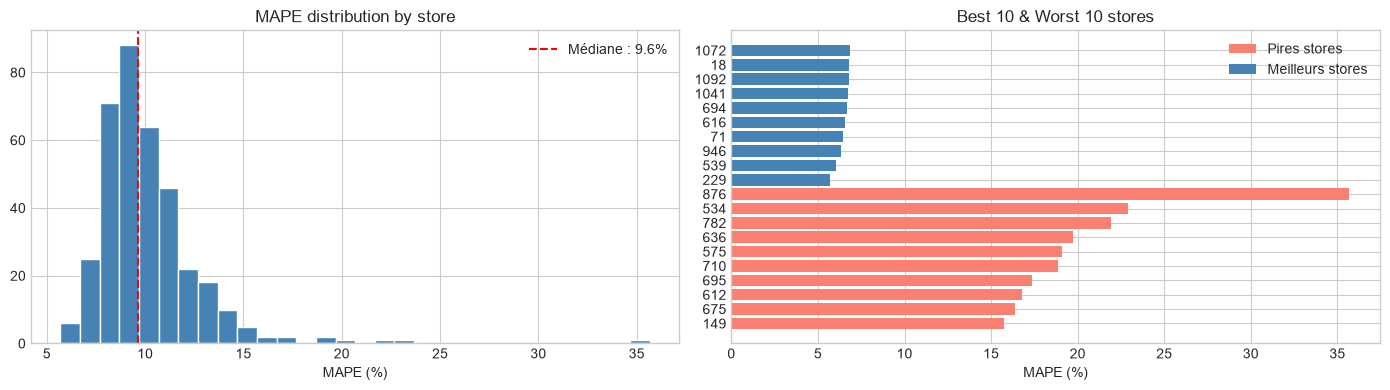

In [34]:
test_df = test_df.copy()
test_df['y_pred'] = y_pred_multi

mape_by_store = test_df.groupby('Store').apply(
    lambda x: mean_absolute_percentage_error(x['Sales'], x['y_pred']) * 100
).reset_index()
mape_by_store.columns = ['Store', 'MAPE']
mape_by_store = mape_by_store.sort_values('MAPE')

print(f"MAPE médian par store : {mape_by_store['MAPE'].median():.2f}%")
print(f"MAPE min : {mape_by_store['MAPE'].min():.2f}% (Store {mape_by_store.iloc[0]['Store']:.0f})")
print(f"MAPE max : {mape_by_store['MAPE'].max():.2f}% (Store {mape_by_store.iloc[-1]['Store']:.0f})")

# MAPE Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mape_by_store['MAPE'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(mape_by_store['MAPE'].median(), color='red', 
                linestyle='--', label=f"Médiane : {mape_by_store['MAPE'].median():.1f}%")
axes[0].set_title('MAPE distribution by store')
axes[0].set_xlabel('MAPE (%)')
axes[0].legend()

# Top 10 meilleurs et pires stores
top10_best  = mape_by_store.head(10)
top10_worst = mape_by_store.tail(10)

axes[1].barh(top10_worst['Store'].astype(str), top10_worst['MAPE'], 
             color='salmon', label='Pires stores')
axes[1].barh(top10_best['Store'].astype(str), top10_best['MAPE'], 
             color='steelblue', label='Meilleurs stores')
axes[1].set_title('Best 10 & Worst 10 stores')
axes[1].set_xlabel('MAPE (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Low-MAPE Stores Analysis

In [35]:
# Stores with MAPE > 15% to be investigated
low_mape_stores = mape_by_store[mape_by_store['MAPE'] > 15]
print(f"Stores avec MAPE > 15% : {len(low_mape_stores)}")

if len(low_mape_stores) > 0:
    print(low_mape_stores.to_string(index=False))
    
    # Common characteristics of stores with low MAPE
    store_info = store[store['Store'].isin(low_mape_stores['Store'])]
    print("\nCaractéristiques :")
    print(store_info[['Store', 'StoreType', 'Assortment', 
                       'CompetitionDistance']].to_string(index=False))

Stores avec MAPE > 15% : 14
 Store      MAPE
   970 15.042330
   427 15.148015
   518 15.209063
   657 15.338897
   149 15.722203
   675 16.405048
   612 16.792552
   695 17.355721
   710 18.866106
   575 19.089320
   636 19.734198
   782 21.942582
   534 22.928294
   876 35.677125

Caractéristiques :
 Store StoreType Assortment  CompetitionDistance
   149         d          a               2610.0
   427         a          c                 70.0
   518         d          c               3330.0
   534         d          a               1200.0
   575         a          a                960.0
   612         d          c               2490.0
   636         c          a                720.0
   657         c          c                 80.0
   675         a          a               2100.0
   695         a          a                550.0
   710         d          a               1500.0
   782         c          c               5390.0
   876         a          a              21790.0
   970     

## Multi-Store Feature Importance

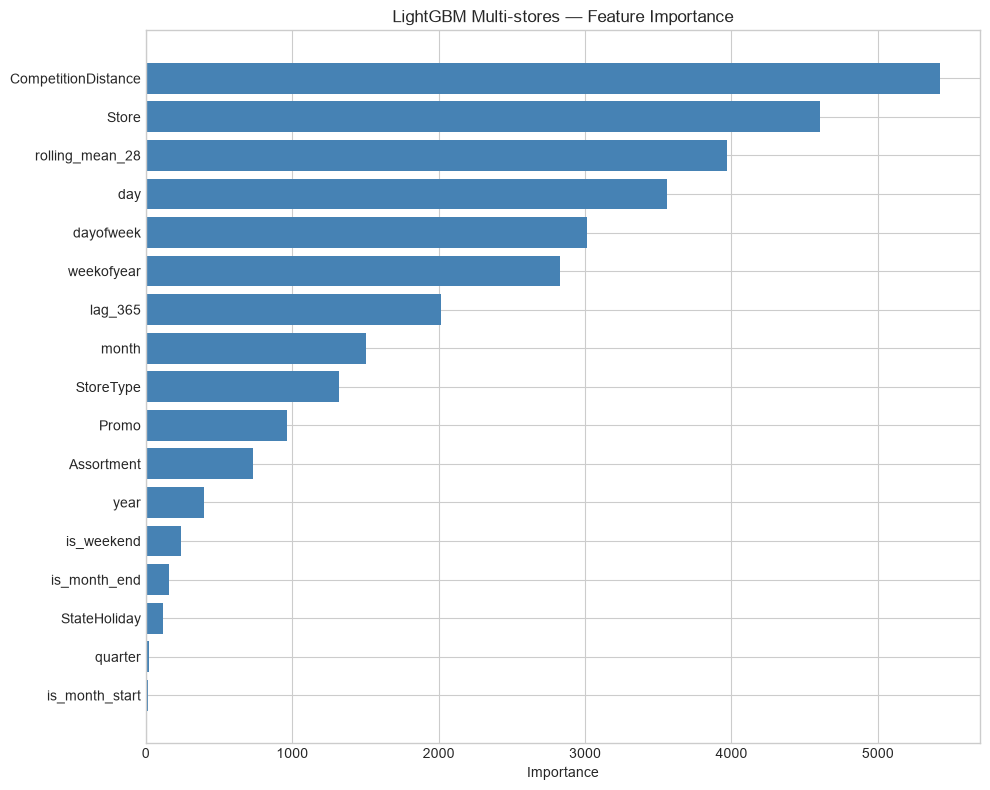


Top 5 features :
            feature  importance
          dayofweek        3012
                day        3557
    rolling_mean_28        3968
              Store        4605
CompetitionDistance        5426


In [36]:
feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': model_multi.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_title('LightGBM Multi-stores — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features :")
print(feat_imp.tail(5)[['feature', 'importance']].to_string(index=False))

# Analysis

### Data Leakage detected and fixed

#### Feature responsible : `sales_vs_rolling`
```python
# Version with leakage — use Sales[d] to predict Sales[d]
df['sales_vs_rolling'] = df['Sales'] / (df['rolling_mean_7'] + 1)

# Version fixed — use Sales[d-1] and prior days
df['sales_vs_rolling'] = grp.shift(1) / (df['rolling_mean_7'] + 1)
```

#### Impact on results

| Metrics | w/ leakage | w/o leakage |
|---|---|---|
| MAPE | 0.85% | 9.9% |
| median MAPE | 0.72% | 9.6% |
| Stores w/ MAPE > 15% | 0 | 10 |
| `Store` dans top 5 features | No | Yes |

### Key-learnings
1. A MAPE < 1% on retail data was suspicious - it is important to check for data leakage
2. After correction, feature importance changed a lot: with leakage the sales vs rolling 
   feature dominated because it encoded the target. After correction, structural date moved
   towards the top.
3. Walk-forward validation would be great to get a better idea of the model performance.

### Shortcomings
- Simple temporal split, no walk-forward which gives an optimistic MAPE.
- Lags not available for horizon > 7.
- The 10 stores with MAPE > 15% should be dealt with differently (more engineered features, dedicted model)

#### Final Results — Model for production


|Model |Scope | MAPE | Notes |
|---|---|---|---|
|Baseline|Multi-stores |17.3% |global mean |
|Prophet |Single-store |7.33% |with Promo regressor |
|LightGBM |Single-store |5.3% |Production features corrected |
|LightGBM |Multi-stores|10.13% |Production features corrected, horizon 42d |

Production features : lag_365, rolling_mean_28, 
date features, store features, promotions